# Exploratory Data Analysis & Intro

## Goal

1.Investigate top-paying roles and skills in the data science industry.
2.Use Python to explore a real-live dataset on job postings.
3.For job-seekers: use these insights to help find the best job opportunities.

## Final Deliverables:

-Create Jupyter Notebookss (showcasing core skills in Python).
-Create a summary page (via README.md) capturing your findings.
-Share this project via GitHub & LinkedIn.

## Questions to Answer

1.What are the most demanded skills for the top 3 most popular data roles?
2.How are in-demand skills trending for Data Analysts?
3.How well do jobs and skills pay for Data Analysts?
4.What is the most optimal skill to learn for Data Analysts? (High Demand AND High Paying)
5.I'll be focusing on Indian Data Analyst roles, but you can adapt to any of the following with the available dataset:

Exploratory Data Analysis for all Data Roles
Roles to Explore

In [13]:
#Importing libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

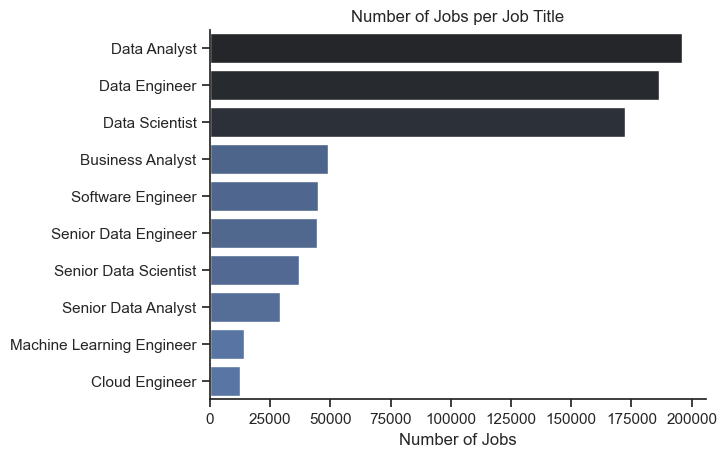

In [14]:
df_plot = df['job_title_short'].value_counts().to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_title_short', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Job Title')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Countries to explore

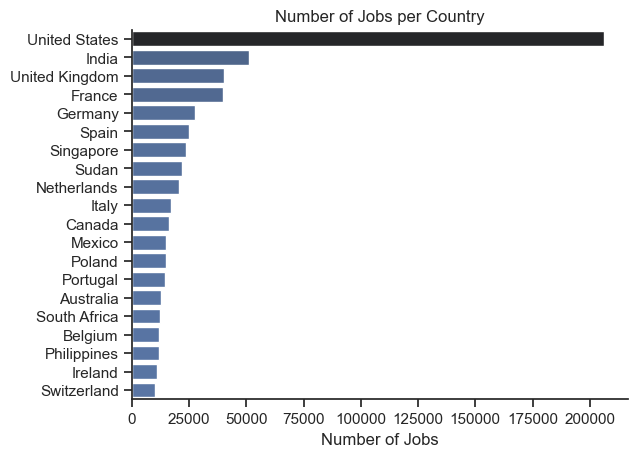

In [12]:
df_plot = df['job_country'].value_counts().to_frame().head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_country', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Country')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Companies to explore 

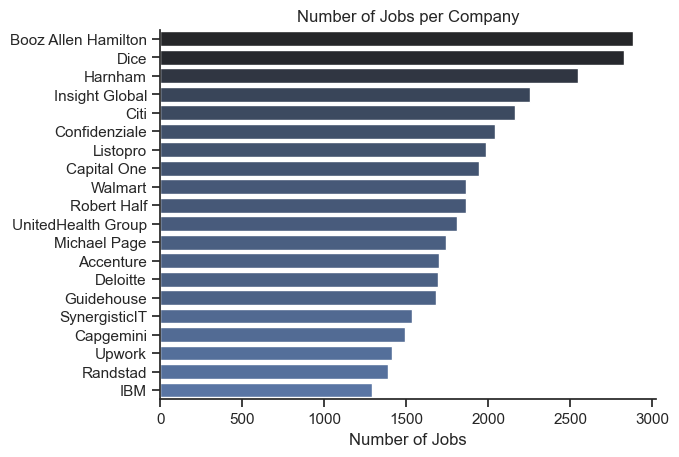

In [15]:
df_plot = df['company_name'].value_counts().to_frame()[1:].head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Number of Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Filter for India Data Analyst roles

In [ ]:
df_DA_IND = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')]

df_DA_IND

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
38,Data Analyst,Data Quality and Governance Analyst 1,India,via Trabajo.org,Full-time,False,India,2023-07-23 13:24:57,False,False,India,NaN,NaN,NaN,"Jones Lang LaSalle IP, Inc","[sql, python, databricks, power bi, excel, wor...","{'analyst_tools': ['power bi', 'excel', 'word'..."
123,Data Analyst,Data Analytics work from home job/internship a...,Anywhere,via LinkedIn,Part-time,True,India,2023-03-07 13:37:56,False,False,India,NaN,NaN,NaN,Inoket Solutions Private Limited,"[sql, excel, word, powerpoint, outlook, power bi]","{'analyst_tools': ['excel', 'word', 'powerpoin..."
159,Data Analyst,Data Analyst,"Hyderabad, Telangana, India",via LinkedIn,Contractor,False,India,2023-11-28 13:12:07,False,False,India,NaN,NaN,NaN,Fusion Plus Solutions Inc,[sql],{'programming': ['sql']}
171,Data Analyst,Data Base work from home job/internship at Mga...,Anywhere,via LinkedIn,Full-time,True,India,2023-01-14 13:11:58,False,False,India,NaN,NaN,NaN,Mgadz Inc,"[sas, sas, sql]","{'analyst_tools': ['sas'], 'programming': ['sa..."
194,Data Analyst,Data Analyst,India,via BeBee India,Full-time,False,India,2023-06-20 13:11:10,False,False,India,NaN,NaN,NaN,QuEST Global Services Pte. Ltd,"[python, sql, excel, ms access, powerpoint]","{'analyst_tools': ['excel', 'ms access', 'powe..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785517,Data Analyst,Analyst - Data Analytics/SQL (2-9 yrs),"Gurugram, Haryana, India",via BeBee India,Full-time,False,India,2023-10-16 06:10:56,False,False,India,NaN,NaN,NaN,iimjobs,[power bi],{'analyst_tools': ['power bi']}
785548,Data Analyst,Data Analyst,"Bengaluru, Karnataka, India",via LinkedIn,Full-time,False,India,2023-01-19 06:14:17,False,False,India,NaN,NaN,NaN,Artech L.L.C.,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
785628,Data Analyst,Data Analyst,"Gurugram, Haryana, India",via LinkedIn,Full-time,False,India,2023-01-09 06:08:12,False,False,India,NaN,NaN,NaN,GUS Global Services India Pvt. Ltd.,"[r, python, sql, sap, power bi, tableau, excel]","{'analyst_tools': ['sap', 'power bi', 'tableau..."
785691,Data Analyst,Business Intelligence Engineer,"Chennai, Tamil Nadu, India",via LinkedIn,Full-time,False,India,2023-01-23 06:12:09,False,False,India,NaN,NaN,NaN,Mobile Programming LLC,"[sql, python, shell, sql server, tableau, micr...","{'analyst_tools': ['tableau', 'microstrategy']..."


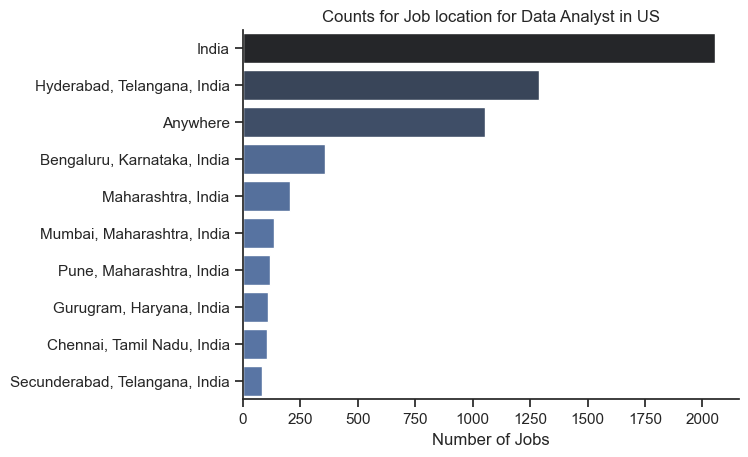

In [ ]:
df_plot = df_DA_IND['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')

sns.barplot(data = df_plot, x = 'count',y='job_location',hue='count',palette='dark:b_r', legend = False )
sns.despine() #Remove border around the graph
plt.title('Counts for Job location for Data Analyst in US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()


### Job Oppurtunities

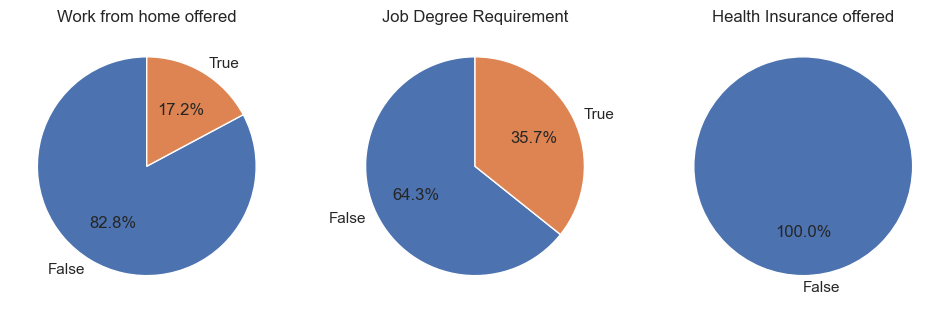

In [ ]:
dict_column = {
    'job_work_from_home' : 'Work from home offered',
    'job_no_degree_mention' : 'Job Degree Requirement',
    'job_health_insurance' : 'Health Insurance offered'
}

fig, ax = plt.subplots(1,3)
fig.set_size_inches((12,5))

for i,(column,title) in enumerate(dict_column.items()):
   counts = df_DA_IND[column].value_counts()
labels = [str(x) for x in counts.index]

ax[i].pie(
    counts,
    labels=labels,
    startangle=90,
    autopct='%1.1f%%'
)
plt.show()

### Companies to explore in India

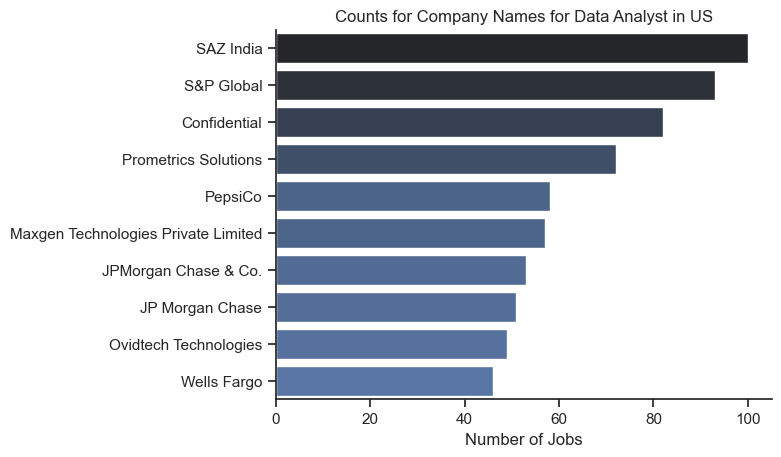

In [ ]:
df_plot = df_DA_IND['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')

sns.barplot(data = df_plot, x = 'count',y='company_name',hue='count',palette='dark:b_r', legend = False )
sns.despine() #Remove border around the graph
plt.title('Counts for Company Names for Data Analyst in US')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()